# Support Vector Machines

* As a classifier, an SVM creates new dimensions from the original data to separate groups.
* The **kernel** determines what kinds of boundaries are available.
* A **linear kernel** draws hyperplanes — for 2D data, just a line.
* An **RBF (Radial Basis Function) kernel** creates non-linear boundaries.

We start with a simple case to build intuition, then show where linear kernels fail and RBF saves us.

## Part 1: Linear SVM on Linearly Separable Data

### Make some blobs
We use  because the data is clean and separable — no preprocessing needed.

Text(0, 0.5, '$x_1$')

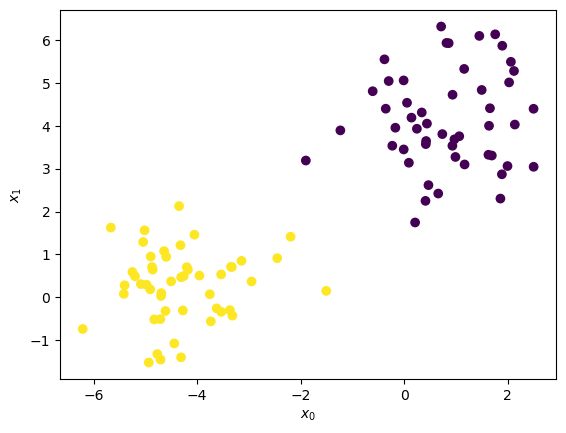

In [1]:
##imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples = 100, n_features=2, centers=2, random_state=3)

## Plot Blobs
plt.scatter(X[:,0], X[:,1], c=y, cmap="viridis")
plt.xlabel(r'$x_0$'); plt.ylabel(r'$x_1$')

### Draw a separation line — just guessing
SVM automates finding the *optimal* version of this line.

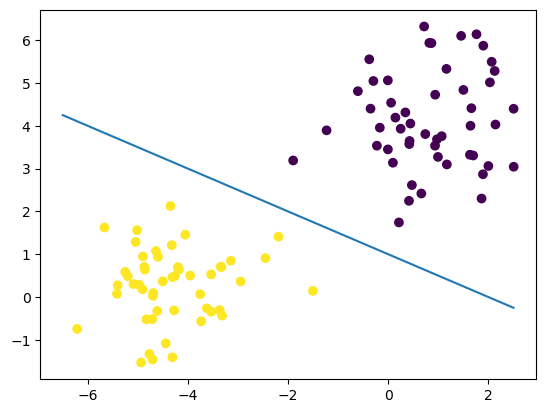

In [2]:
## Make guess for separation line
plt.scatter(X[:,0], X[:,1], c=y, cmap="viridis")

xx = np.linspace(-6.5, 2.5)

#yy = -1*xx
#yy = -2 * xx - 1
yy = -0.5 * xx + 1
plt.plot(xx,yy)

## Part 2: When Linear SVM Fails — The RBF Kernel

Blobs are easy. Now let's try data where no straight line can separate the classes.
 creates two concentric rings — impossible to split with a hyperplane.

## Let's make some circles

Text(0, 0.5, '$x_1$')

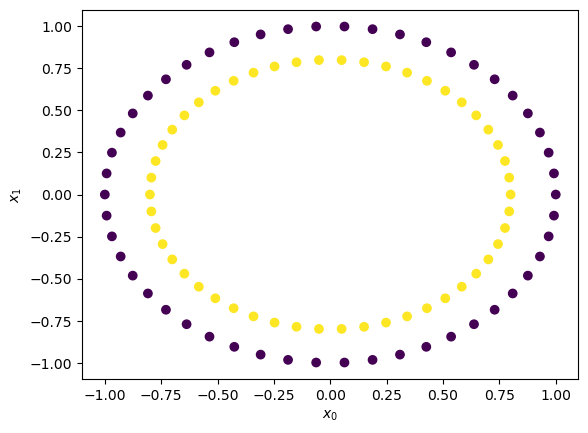

In [1]:
##imports
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import make_circles
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

X,y = make_circles(n_samples = 100, random_state = 3)

## Plot Circles
plt.scatter(X[:,0], X[:,1], c=y)
plt.xlabel(r'$x_0$'); plt.ylabel(r'$x_1$')

## Let's look at the data in 3D

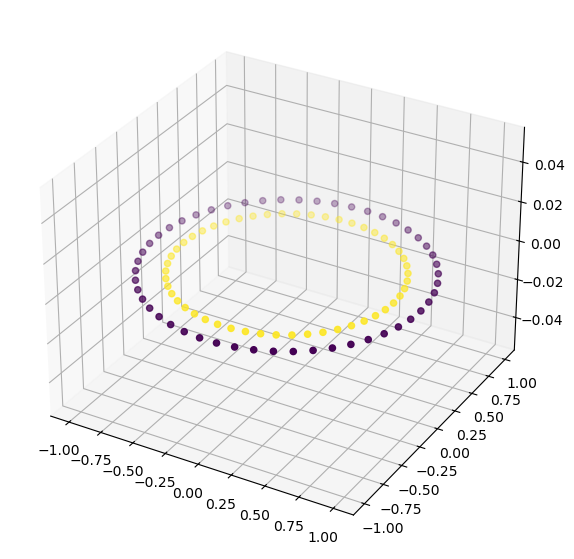

In [2]:
fig = plt.figure(figsize = (10, 7))
ax = plt.axes(projection ="3d")

ax.scatter3D(X[:,0], X[:,1], 0, c=y)

## Let's make a little more data

Text(0, 0.5, '$x_1$')

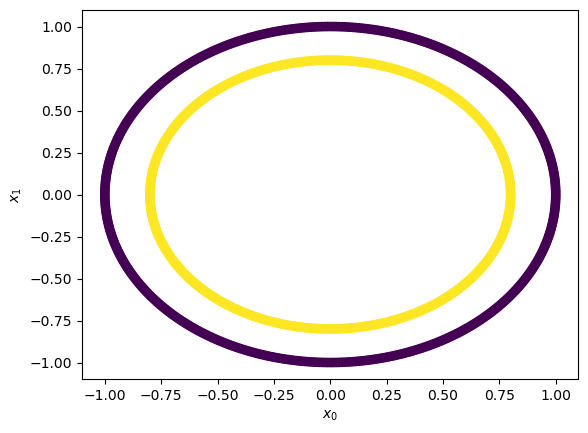

In [3]:
X,y = make_circles(n_samples = 1000, random_state = 3)

## Plot Blobs
plt.scatter(X[:,0], X[:,1], c=y)
plt.xlabel(r'$x_0$'); plt.ylabel(r'$x_1$')

## Let's train up a linear SVM
* This is what we did last class; but now we have split the data

In [4]:
## Split the data
train_vectors, test_vectors, train_labels, test_labels = train_test_split(X, y, test_size=0.25)

## Fit with a linear kernel
cls = SVC(kernel="linear", C=10)
cls.fit(train_vectors,train_labels)

## Print the accuracy
print('Accuracy: ', cls.score(test_vectors, test_labels))

Accuracy:  0.476


## Let's check the report and confusion matrix
* We want more details than simply accuracy

In [6]:
## Use the model to predict
y_pred = cls.predict(test_vectors)

print("Classification Report:\n", classification_report(test_labels, y_pred))

print("Confusion Matrix:\n", confusion_matrix(test_labels, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       131
           1       0.48      1.00      0.64       119

    accuracy                           0.48       250
   macro avg       0.24      0.50      0.32       250
weighted avg       0.23      0.48      0.31       250

Confusion Matrix:
 [[  0 131]
 [  0 119]]


/Users/caballero/anaconda3/envs/teaching/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/caballero/anaconda3/envs/teaching/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/caballero/anaconda3/envs/teaching/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

## Let's look at the ROC curve and compute the AUC

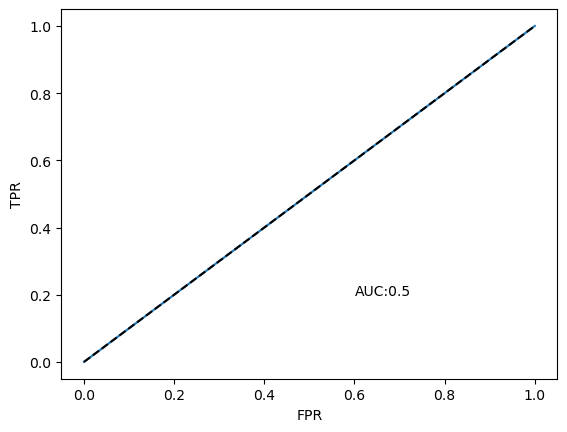

In [7]:
## Construct the ROC and the AUC
fpr, tpr, thresholds = roc_curve(test_labels, y_pred)
auc = np.round(roc_auc_score(test_labels, y_pred),3)

plt.plot(fpr,tpr)
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.text(0.6,0.2, "AUC:"+str(auc));

## The Linear Kernel Absolutely Failed!

### Let's use RBF instead and see what happens

1. Train the model
2. Test the model
3. Evalaute the model: accuracy, scores, confusion matrix, ROC, AUC

## Train the model and start evaluating it

In [8]:
## Fit with a RBF kernel
cls_rbf = SVC(kernel="rbf", C=10)
cls_rbf.fit(train_vectors,train_labels)

## Print the accuracy
print('Accuracy: ', cls_rbf.score(test_vectors, test_labels))

Accuracy:  1.0


## Use the model to predict and report out

In [9]:
## Use the model to predict
y_pred = cls_rbf.predict(test_vectors)

print("Classification Report:\n", classification_report(test_labels, y_pred))

print("Confusion Matrix:\n", confusion_matrix(test_labels, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       131
           1       1.00      1.00      1.00       119

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250

Confusion Matrix:
 [[131   0]
 [  0 119]]


## Construct the ROC and the AUC

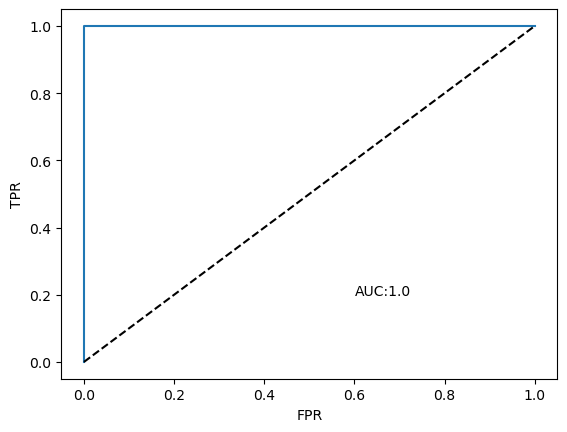

In [10]:
## Construct the ROC and the AUC
fpr, tpr, thresholds = roc_curve(test_labels, y_pred)
auc = np.round(roc_auc_score(test_labels, y_pred),3)

plt.plot(fpr,tpr)
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.text(0.6,0.2, "AUC:"+str(auc));

## Takeaways

* Linear SVM: 47.6% accuracy on circles — no better than random.
* RBF SVM: 100% accuracy — same data, different kernel.
* **The kernel choice matters.** Use linear when data is linearly separable; try RBF when it is not.
* In Activity 02 you can swap  for  in your SVC to experiment.